# MedStock-AU: Pharmaceutical Demand Forecasting
## Module 4 — Anomaly Detection: Isolation Forest

**Author:** Amanda  
**Date:** April 2026  

---

### Overview

This notebook applies **Isolation Forest** to detect abnormal demand patterns across all Sydney pharmacy locations.

Anomalies in pharmaceutical demand may indicate:
- **Disease outbreaks** — sudden spike in respiratory/analgesic medications
- **Supply chain disruptions** — unexpected stockouts
- **Data entry errors** — implausible demand values
- **Panic buying events** — e.g. COVID-19 related surges

### Why Isolation Forest?
Isolation Forest is an **unsupervised** anomaly detection algorithm that:
- Does not require labelled anomaly data
- Works well with high-dimensional, multi-feature data
- Is computationally efficient for large datasets
- Naturally handles the skewed distributions seen in pharmacy demand data

### Approach
1. Engineer features per medication-location pair
2. Train Isolation Forest on normal demand patterns
3. Flag anomalies and analyse their characteristics
4. Compare with the rolling-mean method used in EDA (Module 2)

---

## 1. Import Libraries & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load processed data
df = pd.read_csv('../data/processed/pharmacy_demand_processed.csv', parse_dates=['date'])

print(f"Dataset shape  : {df.shape}")
print(f"Date range     : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Columns        : {df.columns.tolist()}")

Dataset shape  : (105216, 20)
Date range     : 2022-01-01 → 2024-12-31
Columns        : ['date', 'location', 'location_type', 'suburb', 'medication', 'category', 'demand_units', 'is_weekend', 'month', 'quarter', 'day_of_week', 'day_of_year', 'year', 'reorder_point', 'unit_cost_aud', 'lead_time_days', 'season', 'rolling_mean', 'rolling_std', 'is_anomaly']


## 2. Feature Engineering for Anomaly Detection

We engineer features that capture the **context** of each demand observation,
helping Isolation Forest distinguish genuine anomalies from normal variation.

In [2]:
df_model = df.sort_values(['location', 'medication', 'date']).copy()

# Group-level rolling features
grp = df_model.groupby(['location', 'medication'])['demand_units']

df_model['rolling_mean_7']  = grp.transform(lambda x: x.shift(1).rolling(7,  min_periods=1).mean())
df_model['rolling_std_7']   = grp.transform(lambda x: x.shift(1).rolling(7,  min_periods=1).std().fillna(0))
df_model['rolling_mean_30'] = grp.transform(lambda x: x.shift(1).rolling(30, min_periods=1).mean())
df_model['rolling_std_30']  = grp.transform(lambda x: x.shift(1).rolling(30, min_periods=1).std().fillna(0))

# Deviation from rolling mean (z-score style)
df_model['z_score_7']  = (df_model['demand_units'] - df_model['rolling_mean_7'])  / (df_model['rolling_std_7']  + 1e-8)
df_model['z_score_30'] = (df_model['demand_units'] - df_model['rolling_mean_30']) / (df_model['rolling_std_30'] + 1e-8)

# Lag features
df_model['lag_1']  = grp.transform(lambda x: x.shift(1))
df_model['lag_7']  = grp.transform(lambda x: x.shift(7))

# Calendar features
df_model['is_weekend']  = df_model['is_weekend']
df_model['month']       = df_model['month']
df_model['day_of_week'] = df_model['day_of_week']
df_model['season_num']  = df_model['season'].map({'Summer': 0, 'Autumn': 1, 'Winter': 2, 'Spring': 3})

# Drop rows with NaN from lag features
df_model = df_model.dropna(subset=['lag_1', 'lag_7', 'rolling_mean_7'])

print(f"Dataset after feature engineering : {df_model.shape}")
print(f"New features added                : z_score_7, z_score_30, lag_1, lag_7, rolling_mean_30, rolling_std_30")

Dataset after feature engineering : (104544, 29)
New features added                : z_score_7, z_score_30, lag_1, lag_7, rolling_mean_30, rolling_std_30


## 3. Train Isolation Forest

We train a single Isolation Forest across all location-medication combinations,
using demand context features as input.

**Key parameter — `contamination`:**  
Set to 0.03 (3%) based on the anomaly rate observed in EDA (≈ 4%).

In [12]:
feature_cols = [
    'demand_units', 'z_score_7', 'z_score_30',
    'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7',
    'rolling_mean_30', 'rolling_std_30',
    'is_weekend', 'month', 'day_of_week', 'season_num'
]

df_model['if_anomaly']    = 0
df_model['anomaly_score'] = 0.0

groups = df_model.groupby(['location', 'medication'])

for (loc, med), group_idx in groups.groups.items():
    group = df_model.loc[group_idx].copy()

    # Exclude stockout days from training
    train_group = group[group['demand_units'] > 0]
    if len(train_group) < 30:
        continue

    X = train_group[feature_cols].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    iso = IsolationForest(
        n_estimators  = 100,
        contamination = 0.03,
        random_state  = 42
    )
    iso.fit(X_scaled)

    preds  = iso.predict(X_scaled)
    scores = iso.score_samples(X_scaled)

    df_model.loc[train_group.index, 'if_anomaly']    = (preds == -1).astype(int)
    df_model.loc[train_group.index, 'anomaly_score'] = scores

# Stockout days always flagged as anomaly
df_model.loc[df_model['demand_units'] == 0, 'if_anomaly'] = 1

total_anomalies = df_model['if_anomaly'].sum()
anomaly_rate    = df_model['if_anomaly'].mean() * 100

print(f"Total anomalies detected : {total_anomalies:,}")
print(f"Anomaly rate             : {anomaly_rate:.2f}%")
print(f"\nAnomalies by location type:")
print(df_model.groupby('location_type')['if_anomaly'].agg(['sum', 'mean']).round(3))

Total anomalies detected : 4,228
Anomaly rate             : 4.04%

Anomalies by location type:
                sum   mean
location_type             
hospital       2144  0.041
retail         2084  0.040


## 4. Anomaly Analysis by Location & Medication

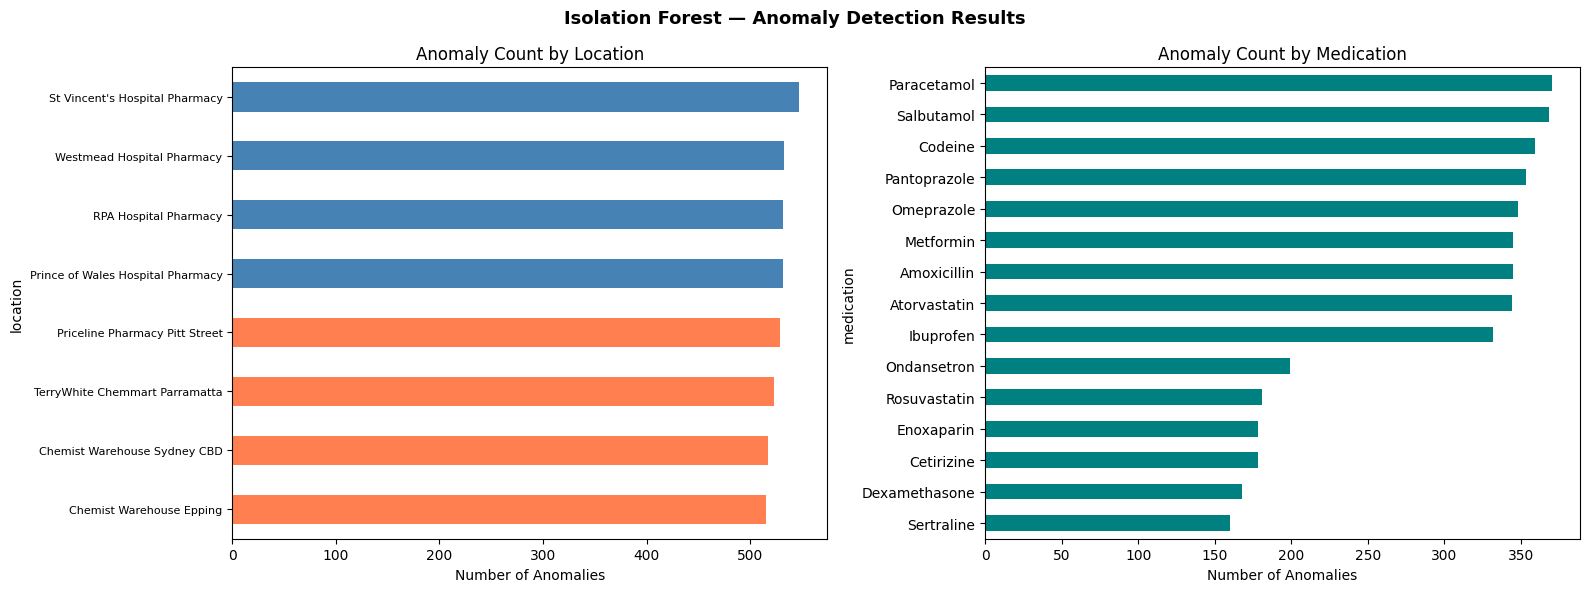

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Isolation Forest — Anomaly Detection Results', fontsize=13, fontweight='bold')

# Anomaly count by location
ax1 = axes[0]
anomaly_by_loc = df_model.groupby('location')['if_anomaly'].sum().sort_values()
colors = ['steelblue' if 'Hospital' in x or 'RPA' in x or
          "St Vincent" in x or 'Prince' in x or 'Westmead' in x
          else 'coral' for x in anomaly_by_loc.index]
anomaly_by_loc.plot(kind='barh', ax=ax1, color=colors)
ax1.set_title('Anomaly Count by Location')
ax1.set_xlabel('Number of Anomalies')
ax1.tick_params(axis='y', labelsize=8)

# Anomaly count by medication
ax2 = axes[1]
anomaly_by_med = df_model.groupby('medication')['if_anomaly'].sum().sort_values()
anomaly_by_med.plot(kind='barh', ax=ax2, color='teal')
ax2.set_title('Anomaly Count by Medication')
ax2.set_xlabel('Number of Anomalies')

plt.tight_layout()
plt.savefig('../reports/04_anomaly_by_location_medication.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Visualise Anomalies on Time Series

We overlay detected anomalies on the RPA Hospital — Paracetamol demand series.

RPA Paracetamol — Total days    : 1089
RPA Paracetamol — Anomalies     : 49 (4.5%)

Top 5 highest anomaly demand days:
            date  demand_units  z_score_7  anomaly_score
64448 2024-05-30          1618   1.262384      -0.704482
64447 2024-05-29          1467   1.227495      -0.668661
64445 2024-05-27          1351   1.946550      -0.656451
64446 2024-05-28          1331   1.294695      -0.663661
64443 2024-05-25          1203   7.686278      -0.670868


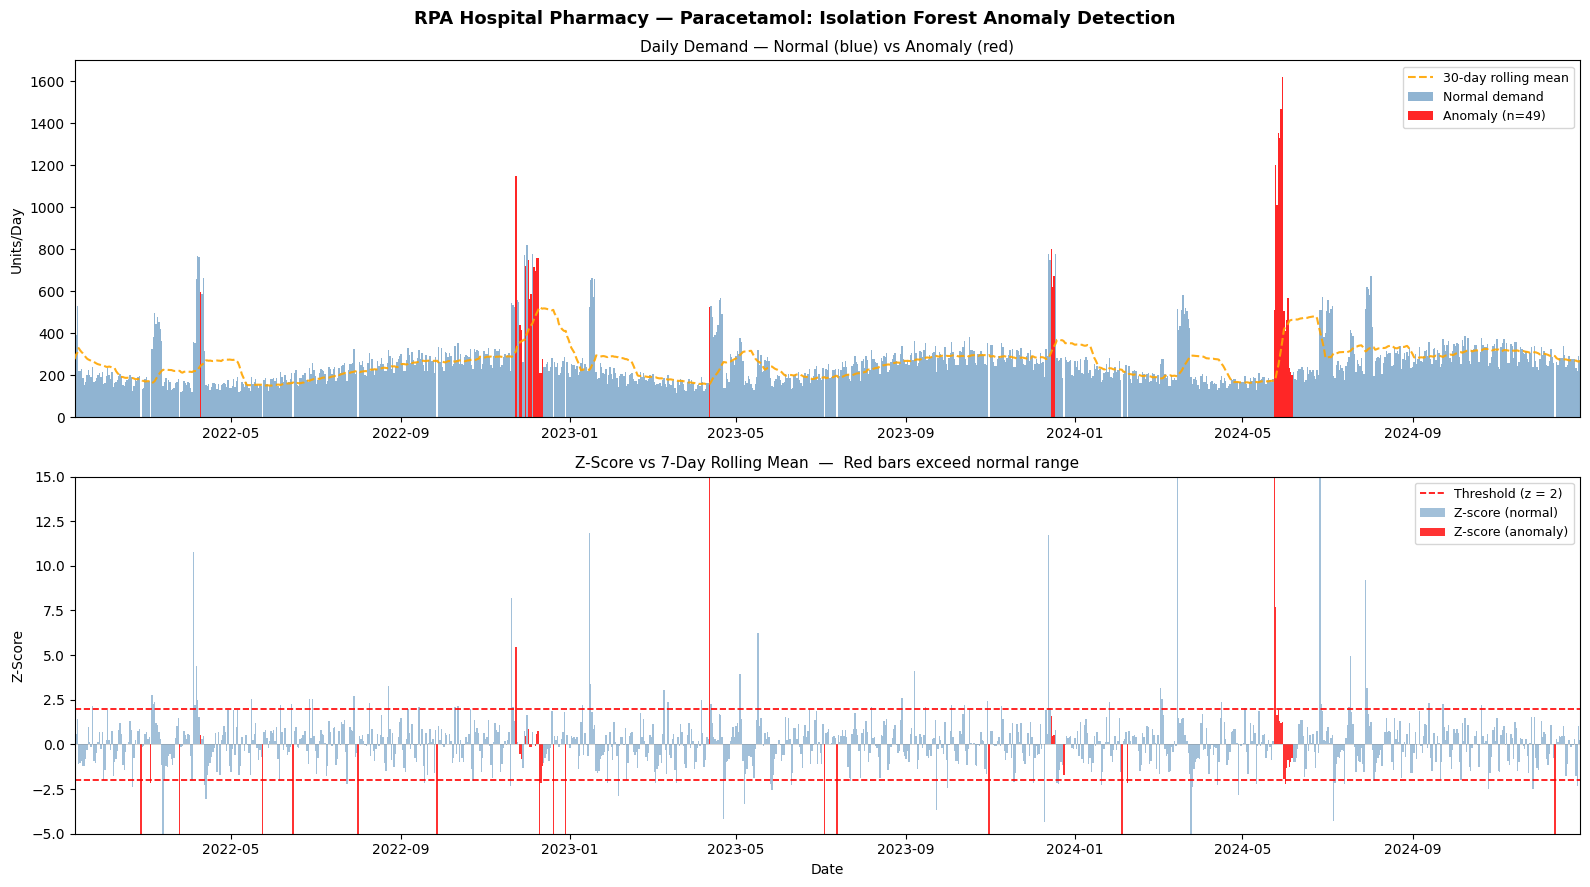

In [18]:
# Filter for RPA + Paracetamol
rpa_para = df_model[
    (df_model['location'] == 'RPA Hospital Pharmacy') &
    (df_model['medication'] == 'Paracetamol')
].copy()

anomalies_rpa = rpa_para[rpa_para['if_anomaly'] == 1]
normal_rpa    = rpa_para[rpa_para['if_anomaly'] == 0]

print(f"RPA Paracetamol — Total days    : {len(rpa_para)}")
print(f"RPA Paracetamol — Anomalies     : {len(anomalies_rpa)} ({len(anomalies_rpa)/len(rpa_para)*100:.1f}%)")
print(f"\nTop 5 highest anomaly demand days:")
print(anomalies_rpa.nlargest(5, 'demand_units')[['date', 'demand_units', 'z_score_7', 'anomaly_score']])

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('RPA Hospital Pharmacy — Paracetamol: Isolation Forest Anomaly Detection',
             fontsize=13, fontweight='bold')

# --- Plot 1: Time series with anomaly highlights ---
ax1 = axes[0]
# Normal days — blue bars
ax1.bar(normal_rpa['date'], normal_rpa['demand_units'],
        color='steelblue', alpha=0.6, width=1, label='Normal demand')
# Anomaly days — red bars
ax1.bar(anomalies_rpa['date'], anomalies_rpa['demand_units'],
        color='red', alpha=0.85, width=1, label=f'Anomaly (n={len(anomalies_rpa)})')
# Rolling mean line
ax1.plot(rpa_para['date'], rpa_para['rolling_mean_30'],
         color='orange', linewidth=1.5, linestyle='--',
         alpha=0.9, label='30-day rolling mean', zorder=5)

ax1.set_title('Daily Demand — Normal (blue) vs Anomaly (red)', fontsize=11)
ax1.set_ylabel('Units/Day')
ax1.legend(fontsize=9)
ax1.set_xlim(rpa_para['date'].min(), rpa_para['date'].max())

# --- Plot 2: Z-score with threshold line ---
ax2 = axes[1]
ax2.bar(normal_rpa['date'], normal_rpa['z_score_7'],
        color='steelblue', alpha=0.5, width=1, label='Z-score (normal)')
ax2.bar(anomalies_rpa['date'], anomalies_rpa['z_score_7'],
        color='red', alpha=0.8, width=1, label='Z-score (anomaly)')
ax2.axhline(y=2,  color='red',  linestyle='--', linewidth=1.2, label='Threshold (z = 2)')
ax2.axhline(y=0,  color='grey', linestyle='-',  linewidth=0.5, alpha=0.5)
ax2.axhline(y=-2, color='red',  linestyle='--', linewidth=1.2)

ax2.set_title('Z-Score vs 7-Day Rolling Mean  —  Red bars exceed normal range', fontsize=11)
ax2.set_ylabel('Z-Score')
ax2.set_xlabel('Date')
ax2.set_ylim(-5, 15)
ax2.legend(fontsize=9)
ax2.set_xlim(rpa_para['date'].min(), rpa_para['date'].max())

plt.tight_layout()
plt.savefig('../reports/04_anomaly_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Compare Isolation Forest vs Rolling Mean Method

In Module 2, we used a simple rolling mean ± 2 std method.  
Here we compare both approaches to justify using Isolation Forest.

=== Method Comparison — RPA Paracetamol ===
Both flagged as anomaly    : 5
Isolation Forest only      : 44
Rolling Mean only          : 27
Neither flagged            : 1013

Isolation Forest anomaly rate : 4.5%
Rolling Mean anomaly rate     : 2.9%


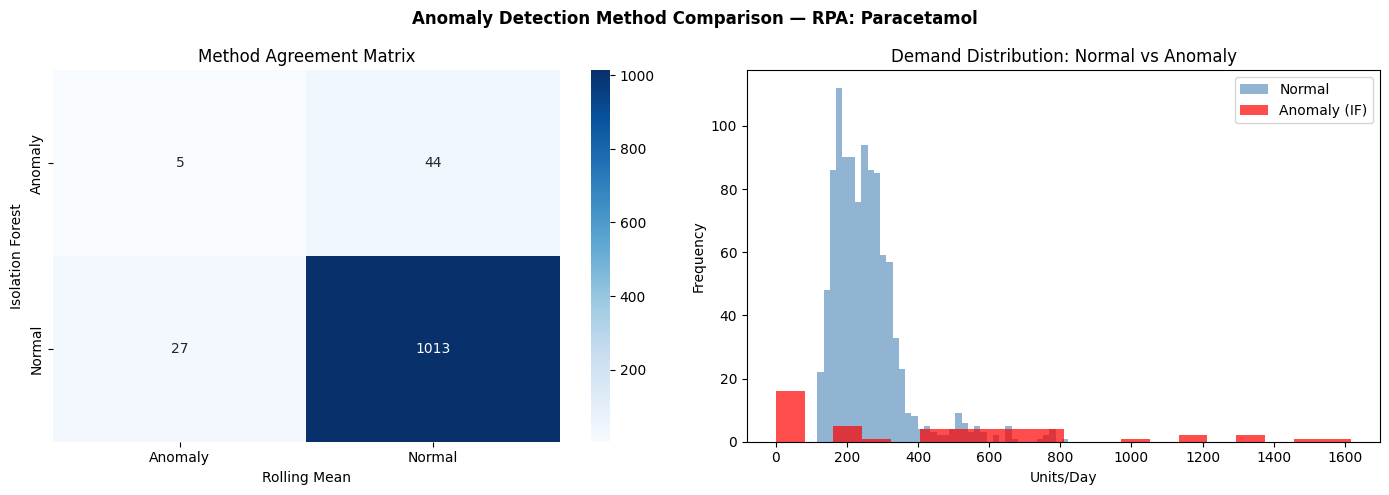

In [15]:
# Agreement between both methods on RPA Paracetamol
rpa_para['rolling_anomaly'] = rpa_para['is_anomaly']  # from EDA

both_flag    = ((rpa_para['if_anomaly'] == 1) & (rpa_para['rolling_anomaly'] == 1)).sum()
if_only      = ((rpa_para['if_anomaly'] == 1) & (rpa_para['rolling_anomaly'] == 0)).sum()
rolling_only = ((rpa_para['if_anomaly'] == 0) & (rpa_para['rolling_anomaly'] == 1)).sum()
neither      = ((rpa_para['if_anomaly'] == 0) & (rpa_para['rolling_anomaly'] == 0)).sum()

print("=== Method Comparison — RPA Paracetamol ===")
print(f"Both flagged as anomaly    : {both_flag}")
print(f"Isolation Forest only      : {if_only}")
print(f"Rolling Mean only          : {rolling_only}")
print(f"Neither flagged            : {neither}")
print(f"\nIsolation Forest anomaly rate : {rpa_para['if_anomaly'].mean()*100:.1f}%")
print(f"Rolling Mean anomaly rate     : {rpa_para['rolling_anomaly'].mean()*100:.1f}%")

# Visualise comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Anomaly Detection Method Comparison — RPA: Paracetamol', fontsize=12, fontweight='bold')

# Agreement heatmap
confusion_data = pd.DataFrame({
    'Isolation Forest': ['Anomaly', 'Anomaly', 'Normal', 'Normal'],
    'Rolling Mean':     ['Anomaly', 'Normal',  'Anomaly', 'Normal'],
    'Count':            [both_flag, if_only, rolling_only, neither]
})
pivot = confusion_data.pivot(index='Isolation Forest', columns='Rolling Mean', values='Count')
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Method Agreement Matrix')

# Anomaly demand distribution
ax2 = axes[1]
ax2.hist(rpa_para[rpa_para['if_anomaly']==0]['demand_units'],
         bins=40, alpha=0.6, color='steelblue', label='Normal')
ax2.hist(rpa_para[rpa_para['if_anomaly']==1]['demand_units'],
         bins=20, alpha=0.7, color='red', label='Anomaly (IF)')
ax2.set_title('Demand Distribution: Normal vs Anomaly')
ax2.set_xlabel('Units/Day')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/04_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Seasonal Anomaly Pattern

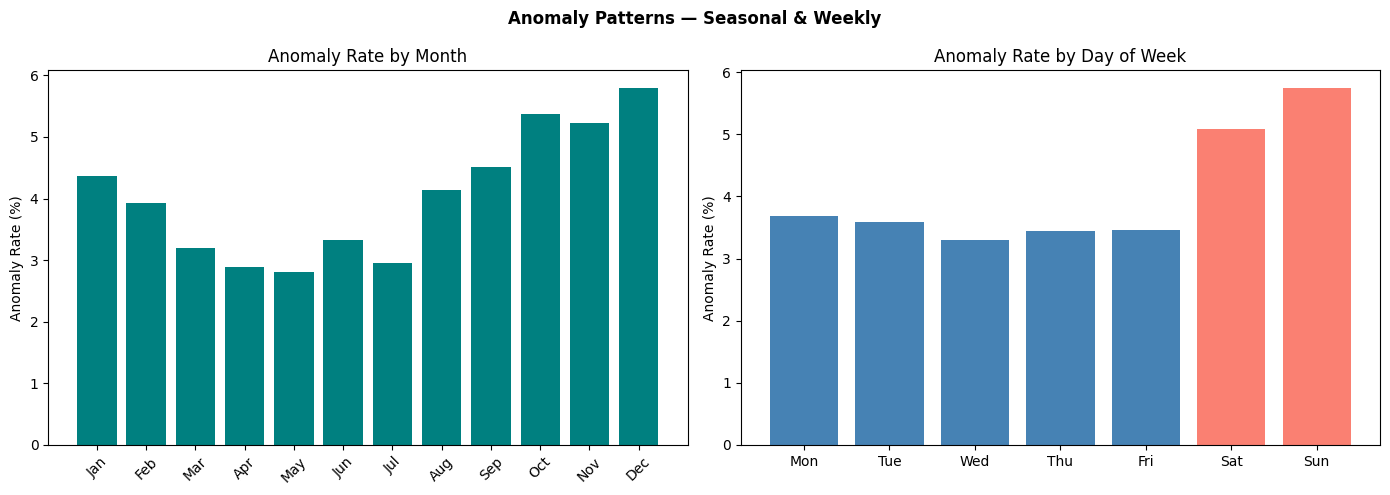

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Anomaly Patterns — Seasonal & Weekly', fontsize=12, fontweight='bold')

# Anomaly rate by month
ax1 = axes[0]
monthly_anomaly = df_model.groupby('month')['if_anomaly'].mean() * 100
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax1.bar(month_labels, monthly_anomaly.values, color='teal')
ax1.set_title('Anomaly Rate by Month')
ax1.set_ylabel('Anomaly Rate (%)')
ax1.tick_params(axis='x', rotation=45)

# Anomaly rate by day of week
ax2 = axes[1]
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily_anomaly = df_model.groupby('day_of_week')['if_anomaly'].mean() * 100
ax2.bar(day_labels, daily_anomaly.values,
        color=['steelblue']*5 + ['salmon']*2)
ax2.set_title('Anomaly Rate by Day of Week')
ax2.set_ylabel('Anomaly Rate (%)')

plt.tight_layout()
plt.savefig('../reports/04_anomaly_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Results

In [17]:
# Save anomaly-flagged dataset
output_path = '../data/processed/pharmacy_demand_with_anomalies.csv'
df_model.to_csv(output_path, index=False)

print(f"Saved to           : {output_path}")
print(f"Shape              : {df_model.shape}")
print(f"Total anomalies    : {df_model['if_anomaly'].sum():,}")
print(f"Anomaly rate       : {df_model['if_anomaly'].mean()*100:.2f}%")
print(f"\nAnomaly breakdown by location type:")
print(df_model.groupby(['location_type', 'if_anomaly']).size().unstack(fill_value=0))

Saved to           : ../data/processed/pharmacy_demand_with_anomalies.csv
Shape              : (104544, 32)
Total anomalies    : 4,228
Anomaly rate       : 4.04%

Anomaly breakdown by location type:
if_anomaly         0     1
location_type             
hospital       50128  2144
retail         50188  2084
